Shape: (10000, 14)

Missing values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


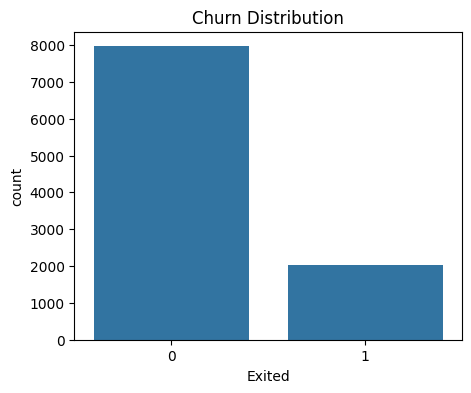


Churn rate: 0.2037

Logistic Regression
Accuracy: 0.8080 | Precision: 0.5891 | Recall: 0.1867 | F1: 0.2836 | AUC: 0.7748
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


Random Forest
Accuracy: 0.8680 | Precision: 0.8235 | Recall: 0.4472 | F1: 0.5796 | AUC: 0.8643
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.82      0.45      0.58       407

    accuracy                           0.87      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000


Gradient Boosting
Accuracy: 0.8670 | Precision: 0.7681 | Recall: 0.4963 | F1: 0.6030 | AUC: 0.8693
              precision    r

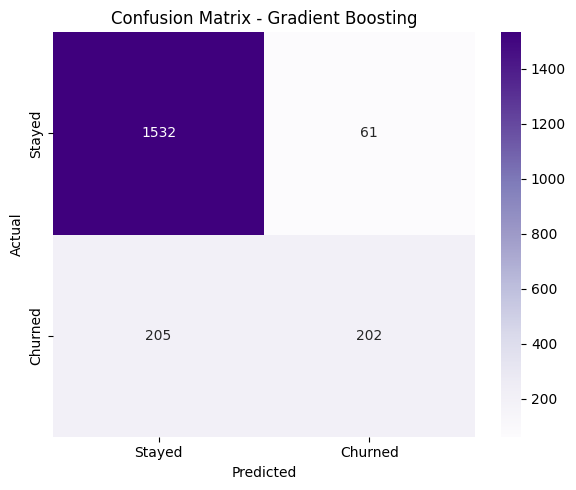

/tmp/ipykernel_23/1972938946.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


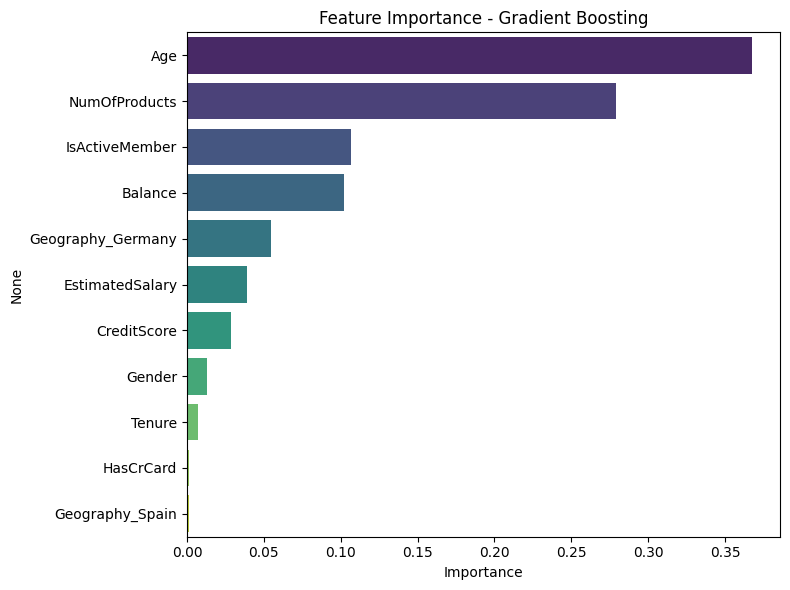


Top 5 Features driving churn:
Age                  0.367371
NumOfProducts        0.278998
IsActiveMember       0.106739
Balance              0.101905
Geography_Germany    0.054633
dtype: float64

Task 3 completed successfully!


In [1]:
# =========================================================
# TASK 3: CUSTOMER CHURN PREDICTION
# CODSOFT Machine Learning Internship
# =========================================================

# ---------- 1. IMPORT LIBRARIES ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score)

# ---------- 2. LOAD DATASET ----------
# IMPORTANT: Update path to match YOUR dataset. Run this first if unsure:
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
data_path = "/kaggle/input/datasets/shantanudhakadd/bank-customer-churn-prediction/Churn_Modelling.csv"
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

# ---------- 3. DROP IRRELEVANT COLUMNS ----------
drop_cols = ["RowNumber", "CustomerId", "Surname"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ---------- 4. CHECK MISSING VALUES ----------
print("\nMissing values:\n", df.isnull().sum())

# ---------- 5. ENCODE CATEGORICAL COLUMNS ----------
le = LabelEncoder()
if "Gender" in df.columns:
    df["Gender"] = le.fit_transform(df["Gender"])   # Male=1, Female=0

if "Geography" in df.columns:
    df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

# ---------- 6. TARGET COLUMN ----------
target_col = "Exited"   # 1 = churned, 0 = stayed

# ---------- 7. EXPLORATORY QUICK LOOK ----------
plt.figure(figsize=(5, 4))
sns.countplot(x=target_col, data=df)
plt.title("Churn Distribution")
plt.savefig("churn_distribution_task3.png", dpi=150)
plt.show()

print("\nChurn rate:", df[target_col].mean())

# ---------- 8. FEATURES / TARGET SPLIT ----------
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------- 9. FEATURE SCALING ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------- 10. MODEL TRAINING & COMPARISON ----------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    results[name] = {"model": model, "f1": f1, "acc": acc}
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(classification_report(y_test, preds))

# ---------- 11. SELECT BEST MODEL ----------
best_model_name = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_model_name]["model"]
print(f"\nBest Model: {best_model_name}")

# ---------- 12. CONFUSION MATRIX ----------
best_preds = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_task3.png", dpi=150)
plt.show()

# ---------- 13. FEATURE IMPORTANCE ----------
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance_task3.png", dpi=150)
    plt.show()

    print("\nTop 5 Features driving churn:")
    print(importances.head())

print("\nTask 3 completed successfully!")